#### Training

In [7]:
import torch
import math
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import LambdaLR
from tqdm.notebook import tqdm
from os.path import join as oj
from torchviz import make_dot
import pandas as pd
import importlib
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

# Import MD-RNN from mdrnn.py
import rmdn
importlib.reload(rmdn)

import rgn
importlib.reload(rgn)

# Import Utility Functions from utils.py
import utils
importlib.reload(utils)

# Import Dataset from decision_dataset.py
import decision_dataset
importlib.reload(decision_dataset)

# Determine device
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

# Default training loop parameters
TRAINING_PARAMS = {
    'hidden_size': 32,
    'initial_learning_rate': 2e-3,
    'min_lr': 1e-5,
    'num_epochs': 64,
    'batch_size': 64
}

2025-06-30 17:29:29,232 - INFO - Using device: cpu.
2025-06-30 17:29:29,234 - INFO - Using device: cpu.


cpu


#### Load and Test Dataloader

In [3]:
cache_folder = '../cache'

raw = pd.read_parquet(oj(cache_folder, 'RRM26-36_sleap_bdf.pq'))
df = raw[['animal', 'session', 'trial', 'offer_prob', 'slp_accept', 'quit', 'slp_tone_onset_time', 'slp_T_Entry_time', 'slp_choice_time', 'reward', 'restaurant']]
df.head(20)

,animal,session,trial,offer_prob,slp_accept,quit,slp_tone_onset_time,slp_T_Entry_time,slp_choice_time,reward,restaurant
0,RRM026,Day151,1,0.0,1.0,NaN,45.860288,46.082765,46.216269,0,1
1,RRM026,Day151,2,20.0,1.0,NaN,71.315418,71.738138,72.305958,1,2
2,RRM026,Day151,3,0.0,1.0,NaN,1736.521459,1737.715123,1738.281459,0,3
3,RRM026,Day151,4,80.0,1.0,NaN,2006.501850,2008.432755,2009.333466,1,4
4,RRM026,Day151,5,20.0,1.0,NaN,2102.127718,2102.557427,2102.857869,0,1
5,RRM026,Day151,6,80.0,1.0,NaN,2388.594829,2389.659098,2389.991514,1,3
6,RRM026,Day151,7,80.0,1.0,NaN,2463.582246,2464.915827,2465.283162,0,4
7,RRM026,Day151,8,80.0,1.0,NaN,2487.729805,2488.497894,2488.896858,1,1
8,RRM026,Day151,9,100.0,1.0,NaN,2538.451878,2539.117926,2539.550938,1,2
9,RRM026,Day151,10,100.0,1.0,NaN,2579.608832,2580.175104,2580.509606,1,3


2025-06-30 17:01:11,739 - INFO - Initialized Dataset in LOAD mode.
2025-06-30 17:01:11,748 - WARNING - Warning: Skipping trial RRM026_Day151_45 due to NaN in critical timing column(s).
2025-06-30 17:01:11,749 - WARNING - Warning: Skipping trial RRM026_Day151_64 due to NaN in critical timing column(s).
2025-06-30 17:01:11,749 - WARNING - Warning: Skipping trial RRM026_Day151_66 due to NaN in critical timing column(s).
2025-06-30 17:01:11,754 - WARNING - Warning: Skipping trial RRM026_Day160_76 due to NaN in critical timing column(s).
2025-06-30 17:01:11,761 - WARNING - Warning: Skipping trial RRM026_Day167_46 due to NaN in critical timing column(s).
2025-06-30 17:01:11,763 - WARNING - Warning: Skipping trial RRM026_Day167_90 due to NaN in critical timing column(s).
2025-06-30 17:01:11,766 - WARNING - Warning: Skipping trial RRM026_Day167_172 due to NaN in critical timing column(s).
2025-06-30 17:01:11,771 - WARNING - Warning: Skipping trial RRM026_Day172_96 due to NaN in critical timing

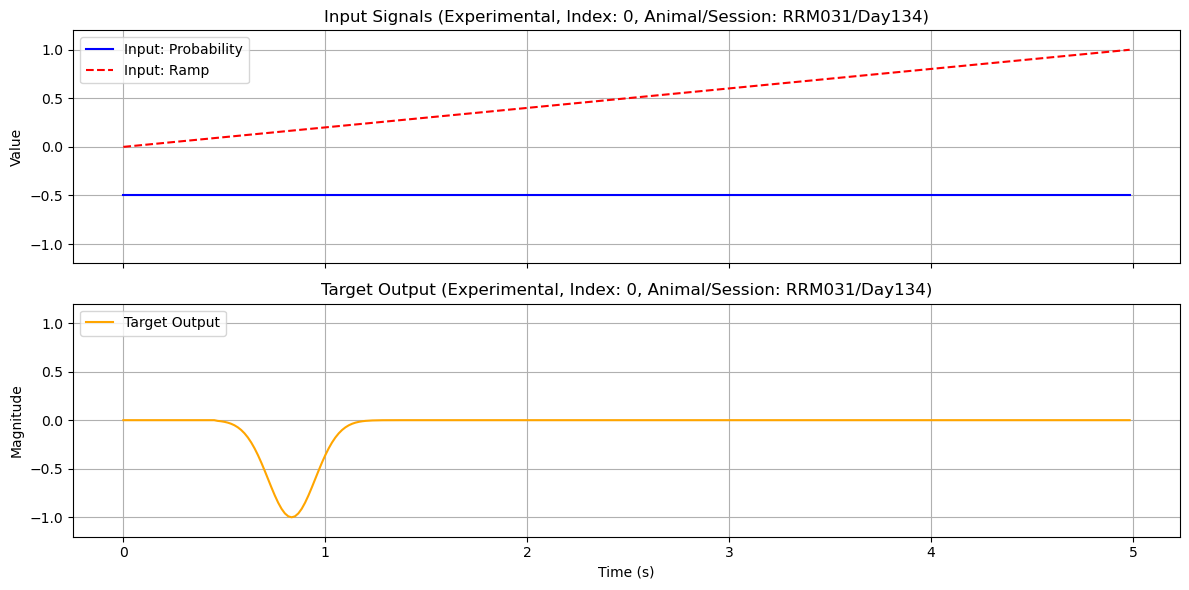

In [4]:
dataset = decision_dataset.DecisionDataset(generate=False, df=df)
#dataset = decision_dataset.DecisionDataset(generate=True, num_samples=8192)
dataset.plot_trial()

dataloader = DataLoader(dataset,
                        batch_size=TRAINING_PARAMS['batch_size'],
                        shuffle=True)

#### Viz Functions


--- Analysis for offer_prob = 0.0 ---


KeyboardInterrupt: 

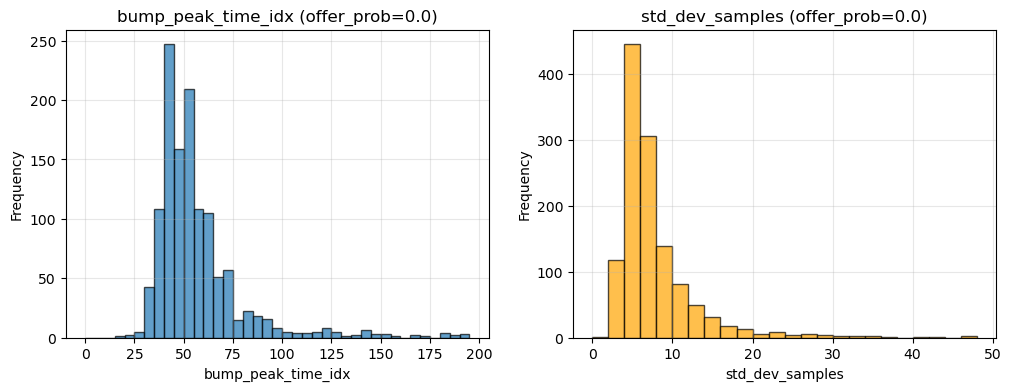

In [ ]:
exp_df = dataset.df

def analysis(df):
    """
    Manual step-by-step analysis
    """
    grouped = df.groupby('offer_prob')
    
    for prob_value, group in grouped:
        print(f"\n--- Analysis for offer_prob = {prob_value} ---")
        
        # Histograms
        plt.figure(figsize=(12, 4))

        bump_bins = np.arange(0,200,5)
        std_bins = np.arange(0,50,2)
        
        plt.subplot(1, 2, 1)
        plt.hist(group['bump_peak_time_idx'].dropna(), bins=bump_bins, alpha=0.7, edgecolor='black')
        plt.title(f'bump_peak_time_idx (offer_prob={prob_value})')
        plt.xlabel('bump_peak_time_idx')
        plt.ylabel('Frequency')
        plt.grid(True, alpha=0.3)
        
        plt.subplot(1, 2, 2)
        plt.hist(group['std_dev_samples'].dropna(), bins=std_bins, alpha=0.7, edgecolor='black', color='orange')
        plt.title(f'std_dev_samples (offer_prob={prob_value})')
        plt.xlabel('std_dev_samples')
        plt.ylabel('Frequency')
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Average of slp_accept
        print(f"Average slp_accept: {group['slp_accept'].mean():.4f}")
        
        # Descriptive statistics
        print("\nDescriptive statistics:")
        for col in ['bump_peak_time_idx', 'std_dev_samples', 'slp_accept']:
            print(f"\n{col}:")
            print(group[col].describe())

analysis(exp_df)

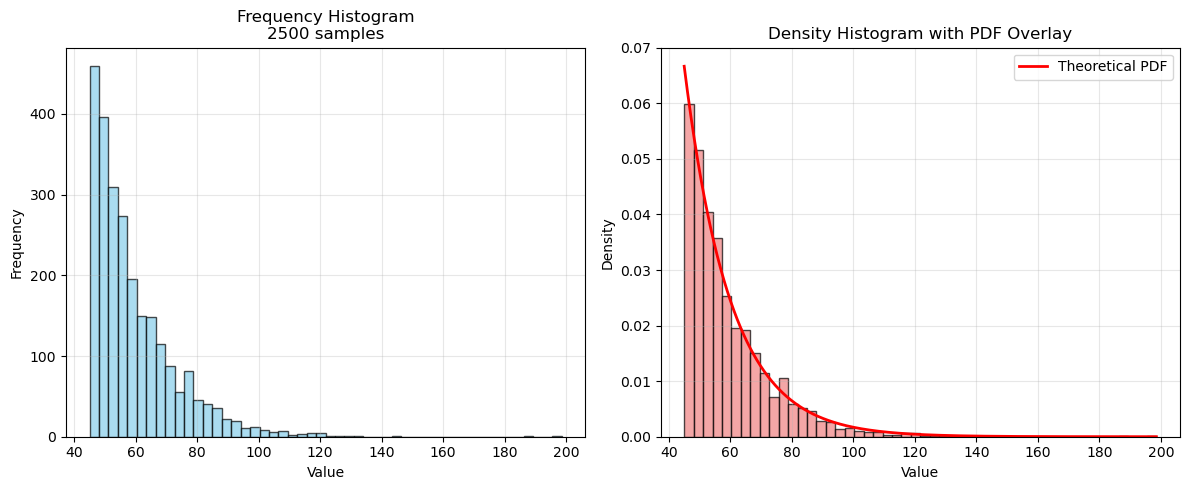

array([77.34863831, 53.09934813, 60.59597311, ..., 54.03850497,
       47.92706927, 45.48515276])

In [ ]:
def plot_exponential_samples(n_samples=2500, scale=15, shift=45, bins=50):
    """
    Generate and plot simplified histogram of exponential distribution samples
    
    Parameters:
    - n_samples: number of samples to generate
    - scale: scale parameter of exponential distribution
    - shift: shift parameter (added to exponential samples)
    - bins: number of histogram bins
    """
    # Generate samples
    samples = np.random.exponential(scale, n_samples) + shift
    
    # Create plot
    plt.figure(figsize=(12, 5))
    
    # Standard histogram
    plt.subplot(1, 2, 1)
    plt.hist(samples, bins=bins, alpha=0.7, edgecolor='black', color='skyblue')
    plt.title(f'Frequency Histogram\n{n_samples} samples')
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)
    
    # Density histogram with PDF overlay
    plt.subplot(1, 2, 2)
    plt.hist(samples, bins=bins, alpha=0.7, edgecolor='black', color='lightcoral', density=True)
    
    # Theoretical PDF overlay
    x_theory = np.linspace(shift, np.max(samples), 1000)
    y_theory = stats.expon.pdf(x_theory - shift, scale=scale)
    plt.plot(x_theory, y_theory, 'r-', linewidth=2, label='Theoretical PDF')
    
    plt.title('Density Histogram with PDF Overlay')
    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return samples

plot_exponential_samples()

In [5]:
def visualize_mixture_components(pi, mu, sigma, output, time, prob):
    fig, axes = plt.subplot_mosaic([['a)', 'b)', 'c)'], ['d)', 'd)', 'd)']], layout='constrained')
    
    fig.suptitle(f'Mixture Density Output, Probability = {prob}')

    pi = pi.squeeze(0)
    mu = mu.squeeze(0).squeeze(-1)
    sigma = sigma.squeeze(0).squeeze(-1)
    output = output.squeeze(0).squeeze(-1)[:-1]

    axes['a)'].plot(time, mu[:, 0], label=rf'$\mu$', color='blue')
    axes['a)'].fill_between(time, mu[:, 0] - sigma[:, 0], mu[:, 0] + sigma[:, 0], color='blue', alpha=0.3, label=rf'$\mu \pm \sigma$')
    axes['a)'].set_title('Accept Gaussian')

    axes['b)'].plot(time, mu[:, 1], label=rf'$\mu$', color='blue')
    axes['b)'].fill_between(time, mu[:, 1] - sigma[:, 1], mu[:, 1] + sigma[:, 1], color='blue', alpha=0.3, label=rf'$\mu \pm \sigma$')
    axes['b)'].set_title('Reject Gaussian')

    axes['c)'].plot(time, pi[:, 0], label='Accept Component')
    axes['c)'].plot(time, pi[:, 1], label='Reject Component')
    axes['c)'].set_title('Mixture Weights')
    axes['c)'].legend()

    axes['d)'].plot(time, output, label='Output')
    axes['d)'].set_title('Output')

    plt.show()

def visualize_gaussian(phi, mu, sigma, output, time, prob):
    fig, axes = plt.subplot_mosaic([['a)', 'b)', 'c)'], ['d)', 'd)', 'd)']], layout='constrained')
    
    fig.suptitle(f'Mixture Density Output, Probability = {prob}')

    phi = phi.squeeze(0).squeeze(-1)
    mu = mu.squeeze(0).squeeze(-1)
    sigma = sigma.squeeze(0).squeeze(-1)
    output = output.squeeze(0).squeeze(-1)[:-1]

    axes['a)'].plot(time, mu, label=rf'$\mu$', color='blue')
    axes['a)'].fill_between(time, mu - sigma, mu + sigma, color='blue', alpha=0.3, label=rf'$\mu \pm \sigma$')
    axes['a)'].set_title('Gaussian')

    axes['b)'].plot(time, phi, label=f'$\Phi$', color='red')
    axes['b)'].set_title('Phi')

    axes['c)'].plot(time, mu * phi, label=rf'$\mu$', color='blue')
    axes['c)'].fill_between(time, np.multiply(mu, phi) - sigma, np.multiply(mu, phi) + sigma, color='blue', alpha=0.3, label=rf'$\mu \pm \sigma$')
    axes['c)'].set_title('Weighted Gaussian')

    axes['d)'].plot(time, output, label='Output')
    axes['d)'].set_title('Output')

    plt.show()

#### Training Loop

Training Progress:   0%|          | 0/64 [00:00<?, ?it/s]

Epoch 1/64:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 1/64, Loss: 0.5941


Epoch 2/64:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 2/64, Loss: -0.0212


...

Epoch 6/64, Loss: -2.2940


Epoch 7/64:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 7/64, Loss: -2.4264


Epoch 8/64:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 8/64, Loss: -2.6182


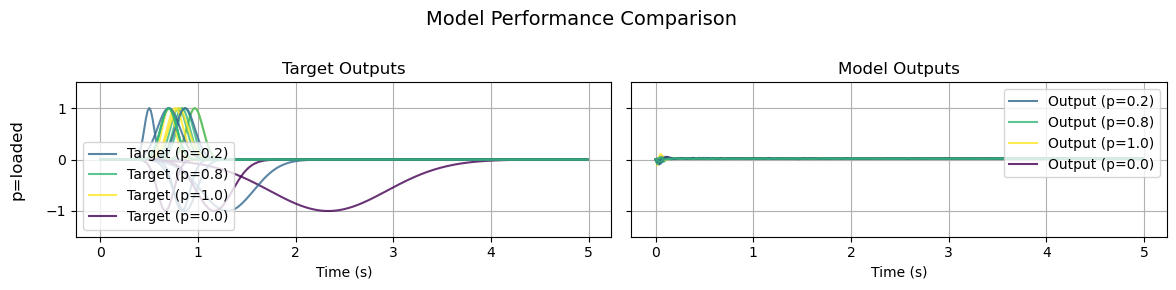

2025-06-30 17:34:07,801 - INFO - Initialized Dataset in GENERATE mode with 64 samples.
/var/folders/bz/kj3xml9x5dg0fmcc4h7r53880000gn/T/ipykernel_35802/1838249750.py:47: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  axes['c)'].fill_between(time, np.multiply(mu, phi) - sigma, np.multiply(mu, phi) + sigma, color='blue', alpha=0.3, label=rf'$\mu \pm \sigma$')


torch.Size([300, 2])


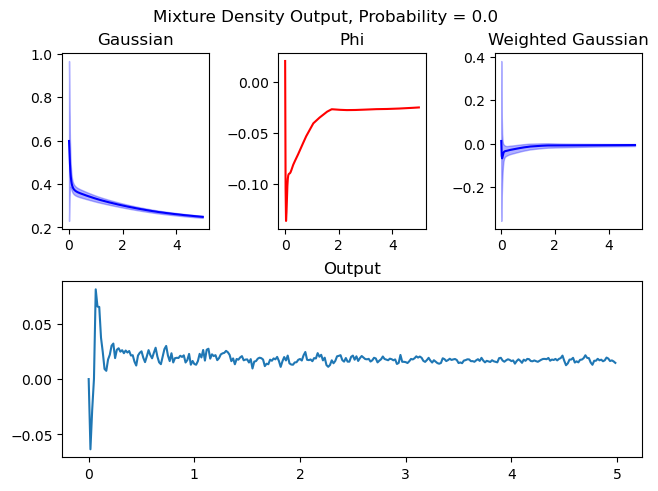

torch.Size([300, 2])


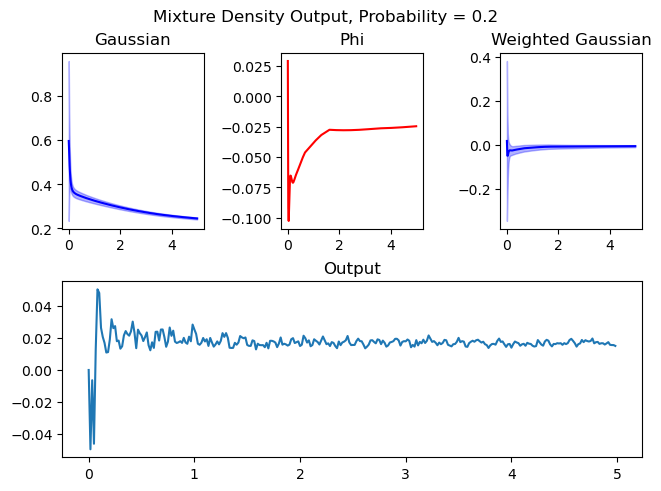

torch.Size([300, 2])


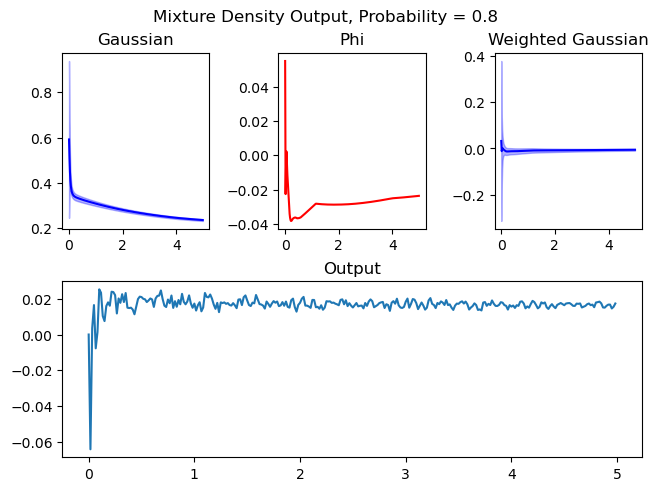

torch.Size([300, 2])


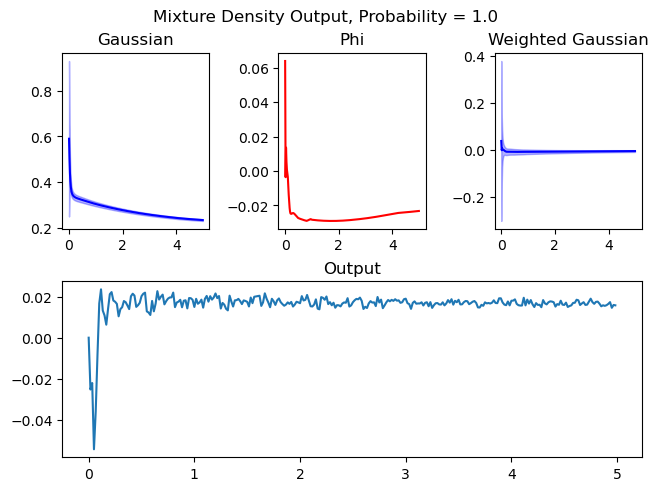

Epoch 9/64:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 9/64, Loss: -2.6656


Epoch 10/64:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 10/64, Loss: -3.0544


Epoch 11/64:   0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 14/64, Loss: -4.6456


Epoch 15/64:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 15/64, Loss: -5.0037


Epoch 16/64:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 16/64, Loss: -5.1433


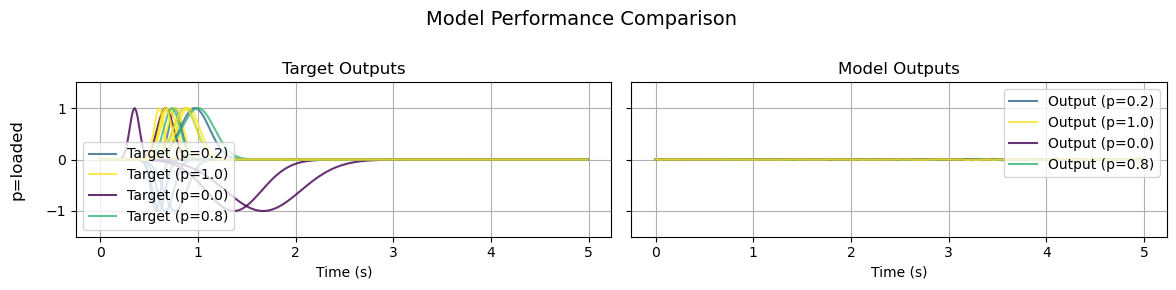

2025-06-30 17:37:46,710 - INFO - Initialized Dataset in GENERATE mode with 64 samples.


torch.Size([300, 2])


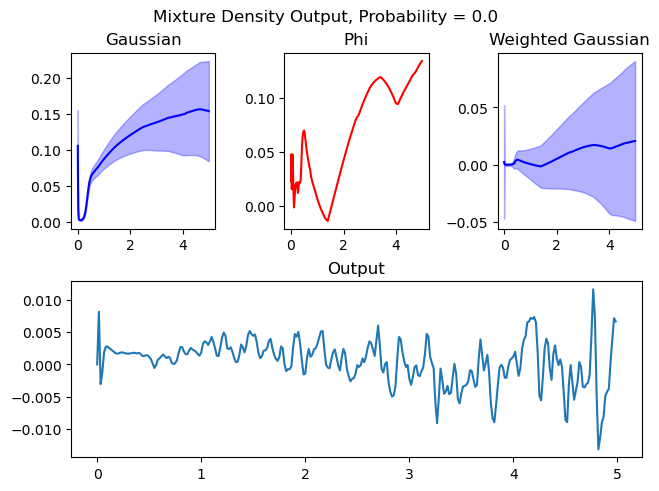

torch.Size([300, 2])


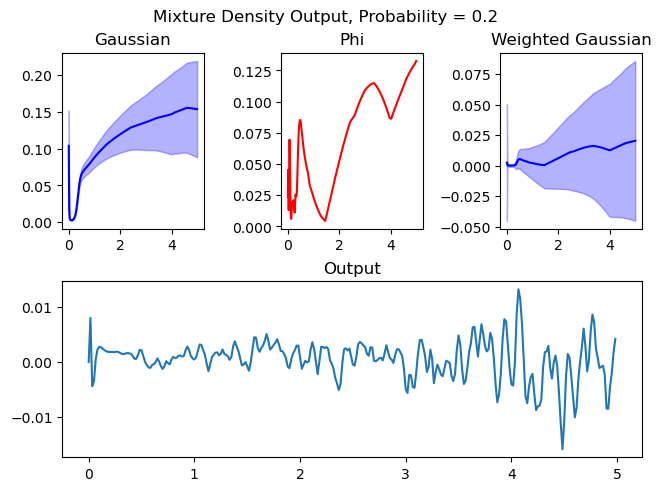

torch.Size([300, 2])


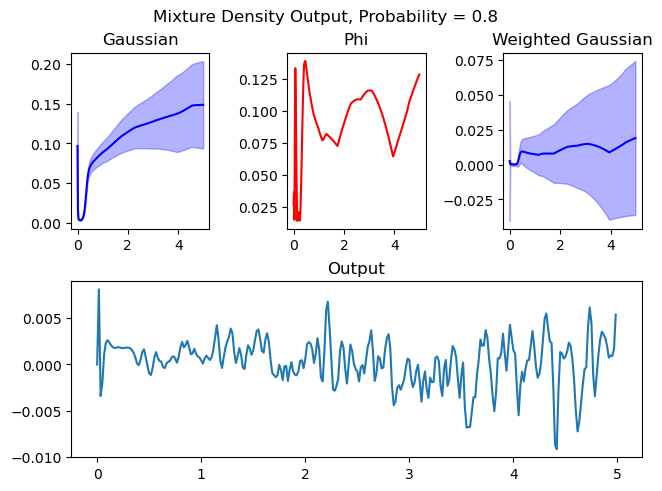

torch.Size([300, 2])


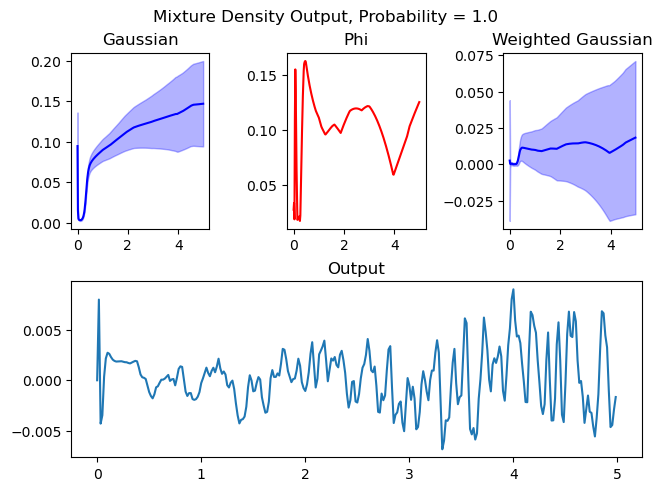

Epoch 17/64:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 17/64, Loss: -5.1449


Epoch 18/64:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 18/64, Loss: -5.1904


Epoch 19/64:   0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 22/64, Loss: -5.1160


Epoch 23/64:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 23/64, Loss: -5.2139


Epoch 24/64:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 24/64, Loss: -5.2681


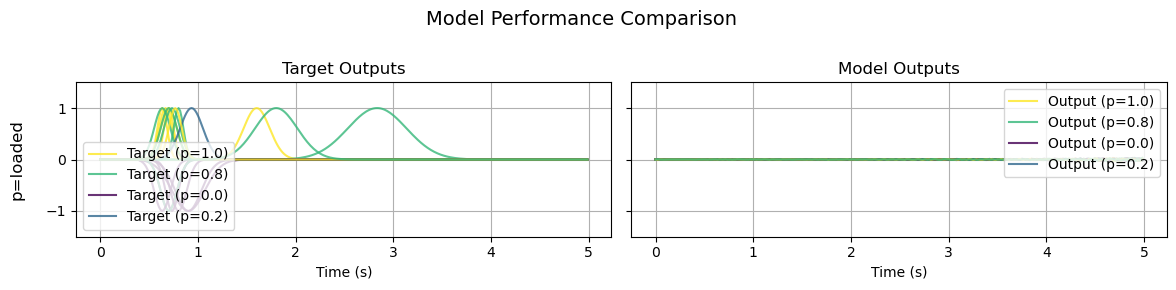

2025-06-30 17:41:21,266 - INFO - Initialized Dataset in GENERATE mode with 64 samples.


torch.Size([300, 2])


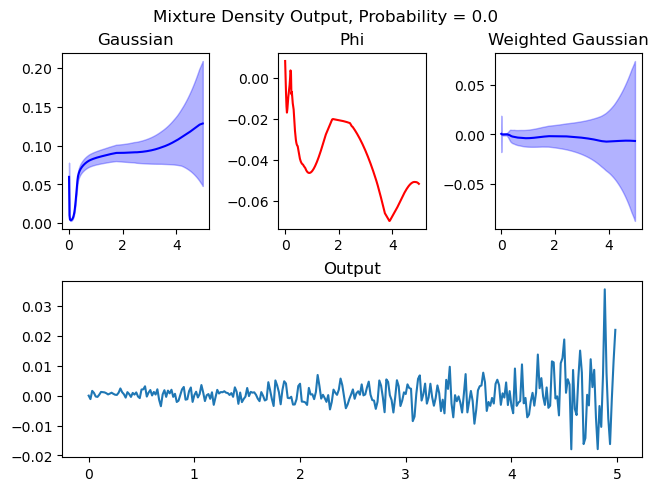

torch.Size([300, 2])


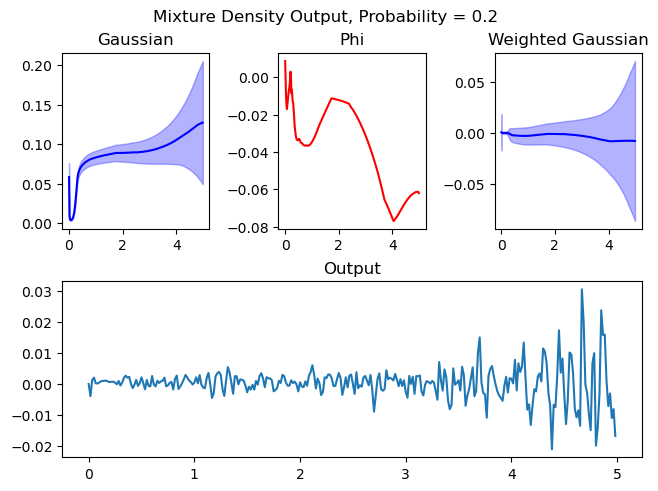

torch.Size([300, 2])


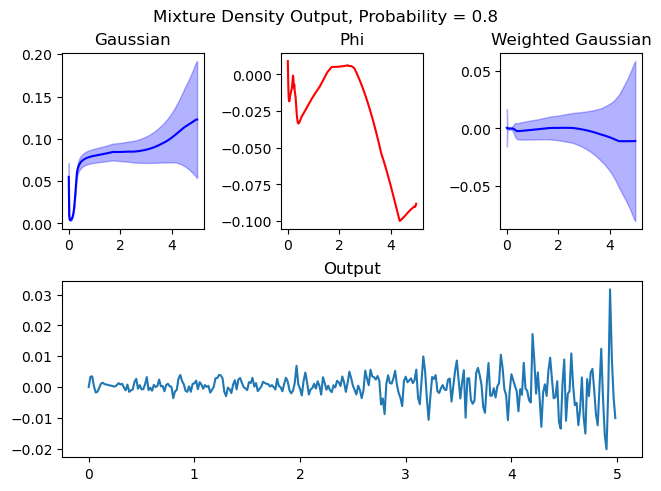

torch.Size([300, 2])


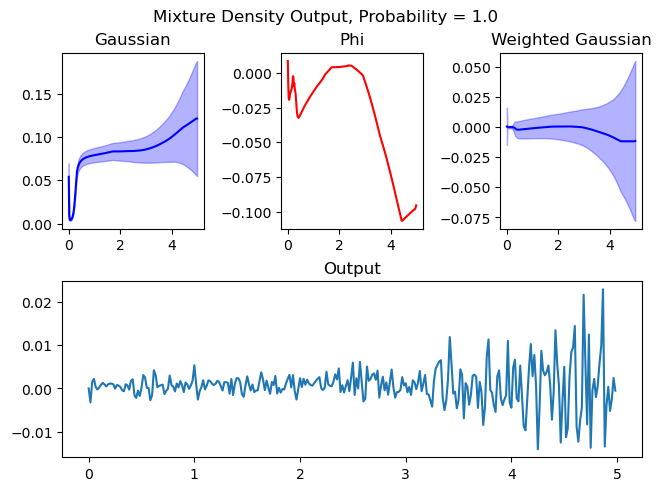

Epoch 25/64:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 25/64, Loss: -5.2608


Epoch 26/64:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 26/64, Loss: -5.2690


Epoch 27/64:   0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 30/64, Loss: -5.1473


Epoch 31/64:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 31/64, Loss: -5.1806


Epoch 32/64:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 32/64, Loss: -5.2263


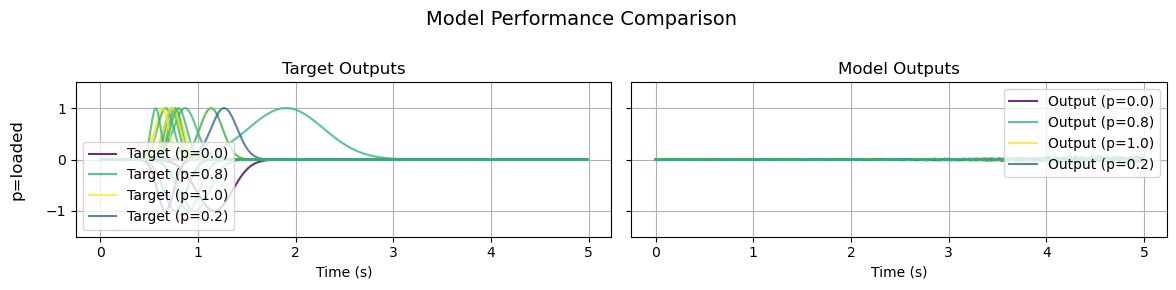

2025-06-30 17:44:56,254 - INFO - Initialized Dataset in GENERATE mode with 64 samples.


torch.Size([300, 2])


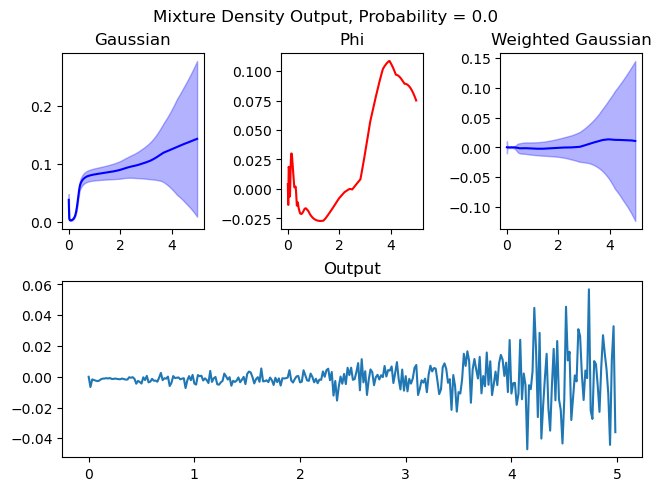

torch.Size([300, 2])


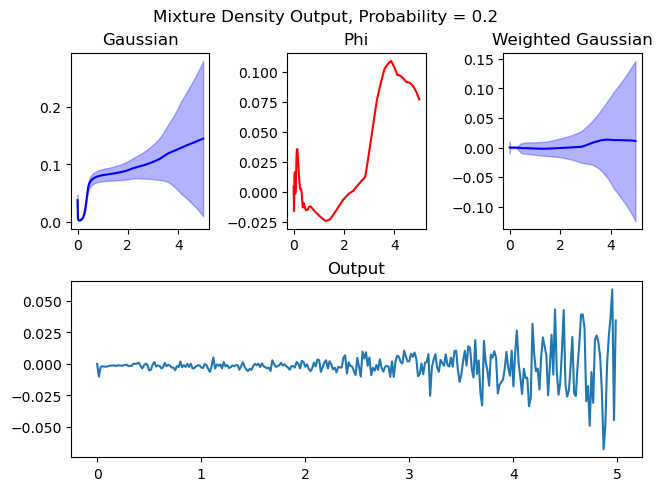

torch.Size([300, 2])


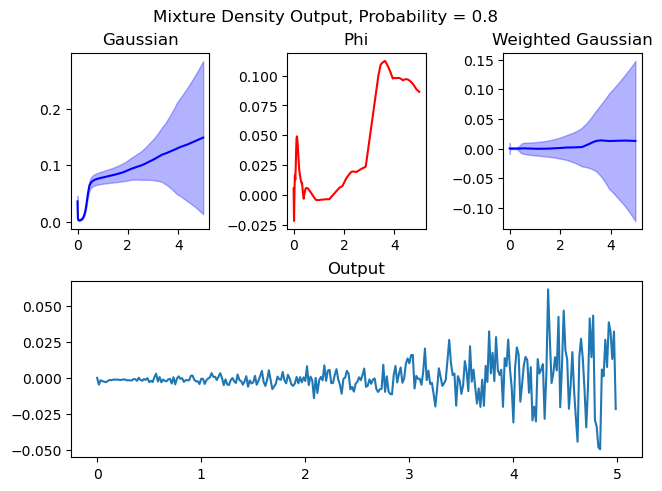

torch.Size([300, 2])


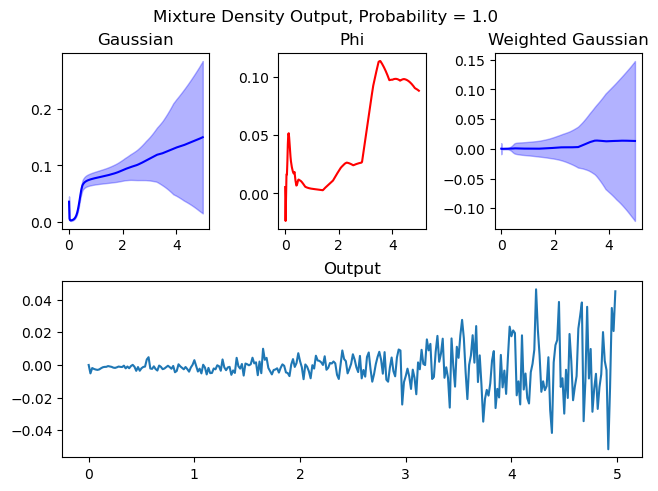

Epoch 33/64:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 33/64, Loss: -5.2393


Epoch 34/64:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 34/64, Loss: -5.2050


Epoch 35/64:   0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 38/64, Loss: -5.1489


Epoch 39/64:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 39/64, Loss: -4.8882


Epoch 40/64:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 40/64, Loss: -5.2116


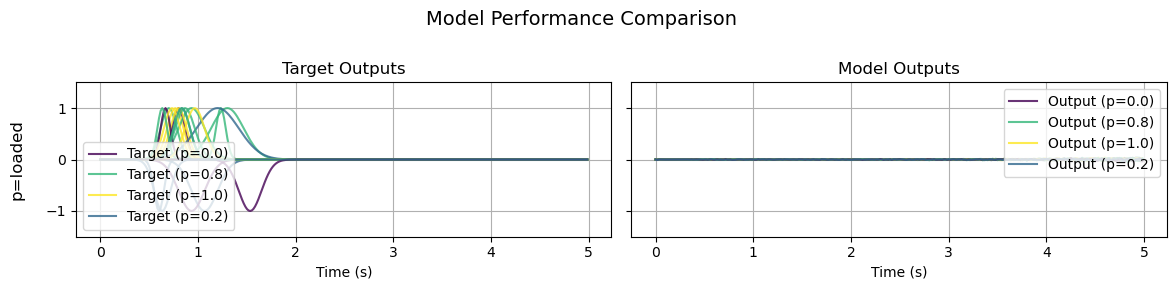

2025-06-30 17:48:32,724 - INFO - Initialized Dataset in GENERATE mode with 64 samples.


torch.Size([300, 2])


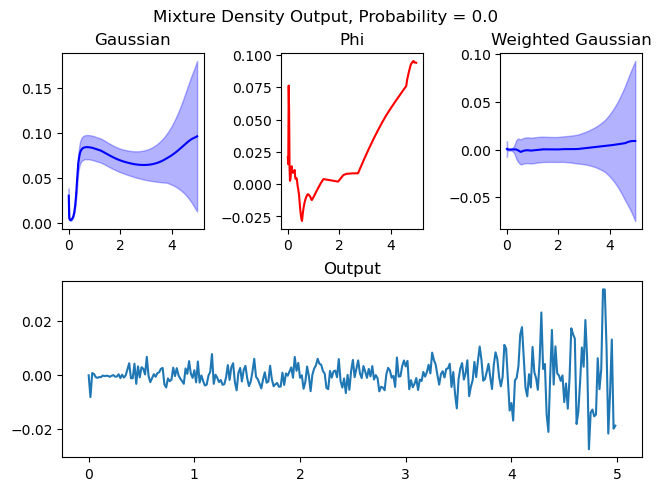

torch.Size([300, 2])


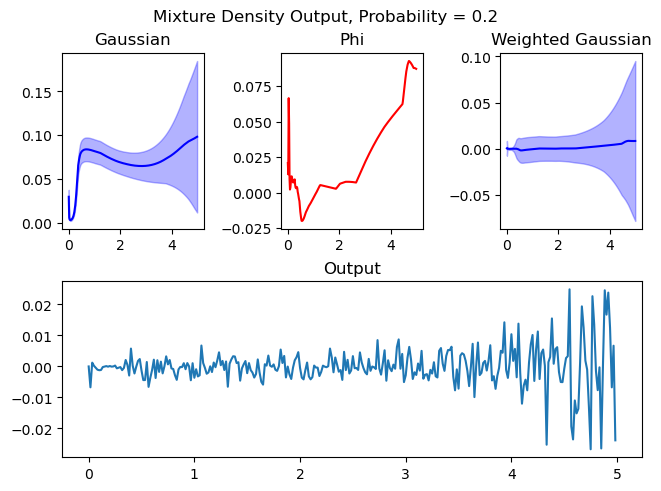

torch.Size([300, 2])


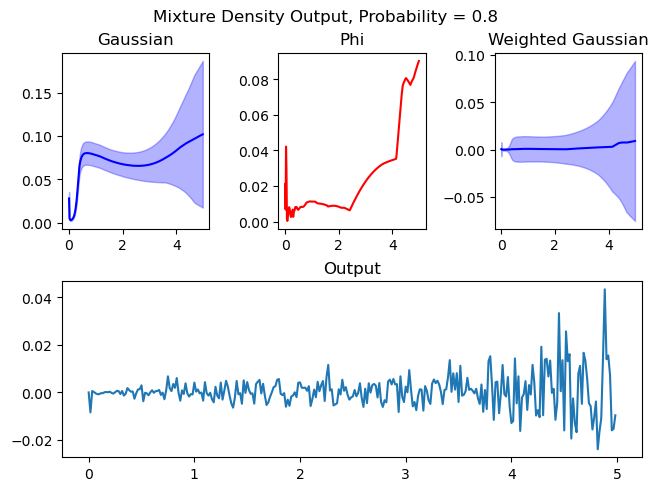

torch.Size([300, 2])


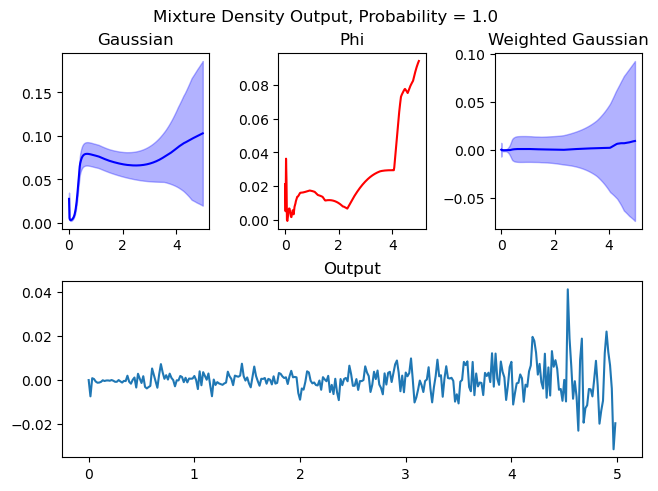

Epoch 41/64:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 41/64, Loss: -5.0506


Epoch 42/64:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 42/64, Loss: -5.2054


Epoch 43/64:   0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 46/64, Loss: -4.6338


Epoch 47/64:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 47/64, Loss: -5.2145


Epoch 48/64:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 48/64, Loss: -5.1064


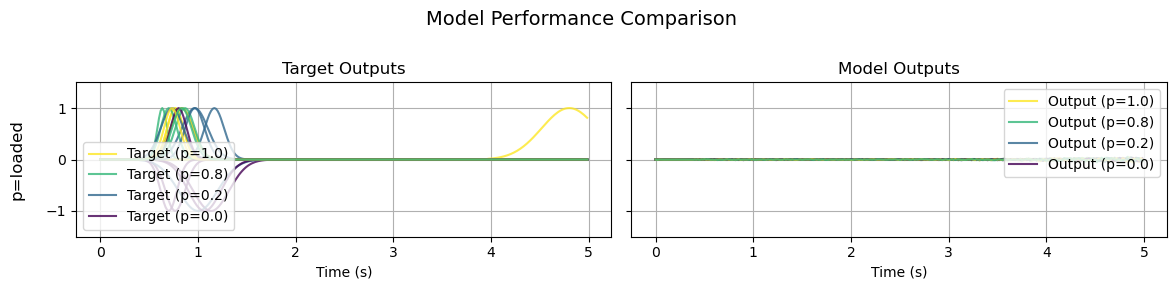

2025-06-30 17:52:10,768 - INFO - Initialized Dataset in GENERATE mode with 64 samples.


torch.Size([300, 2])


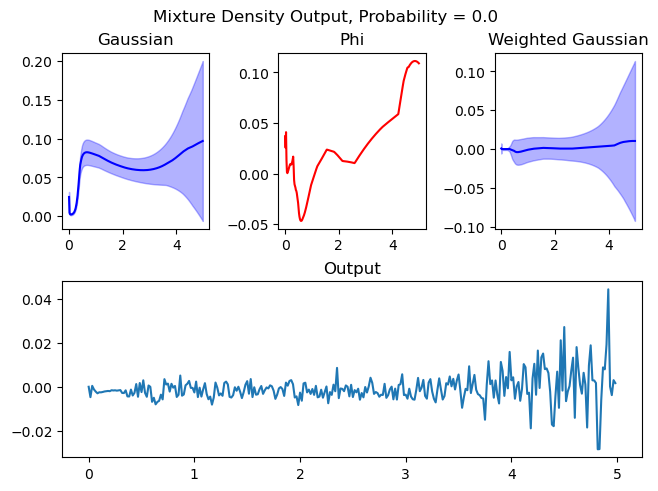

torch.Size([300, 2])


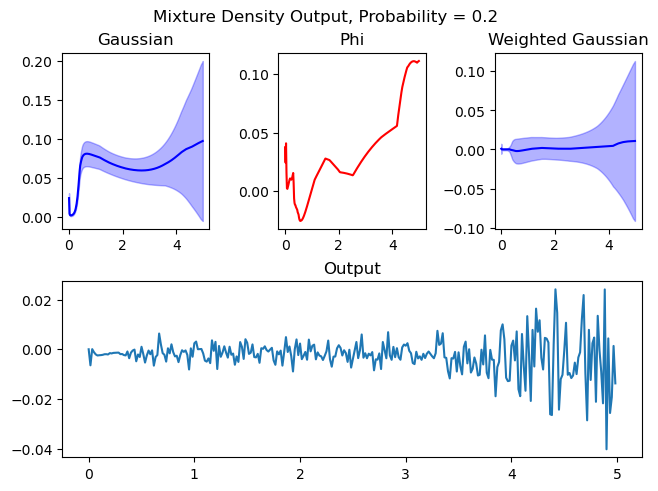

torch.Size([300, 2])


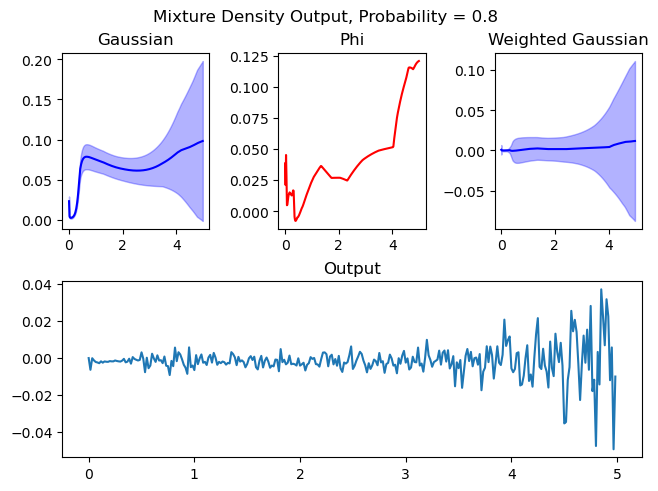

torch.Size([300, 2])


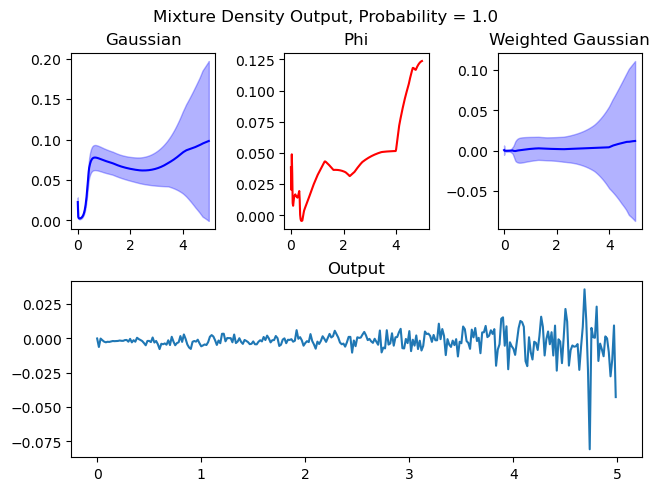

Epoch 49/64:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 49/64, Loss: -5.1505


Epoch 50/64:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 50/64, Loss: -4.6100


Epoch 51/64:   0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 54/64, Loss: -4.7740


Epoch 55/64:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 55/64, Loss: -4.9755


Epoch 56/64:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 56/64, Loss: -4.6922


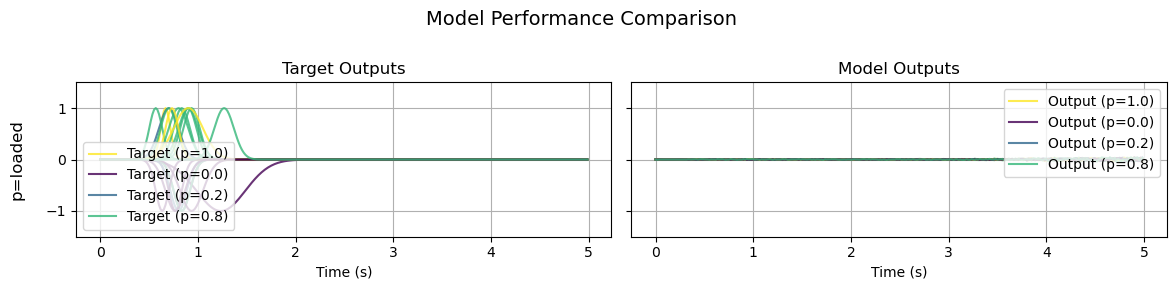

2025-06-30 17:55:49,271 - INFO - Initialized Dataset in GENERATE mode with 64 samples.


torch.Size([300, 2])


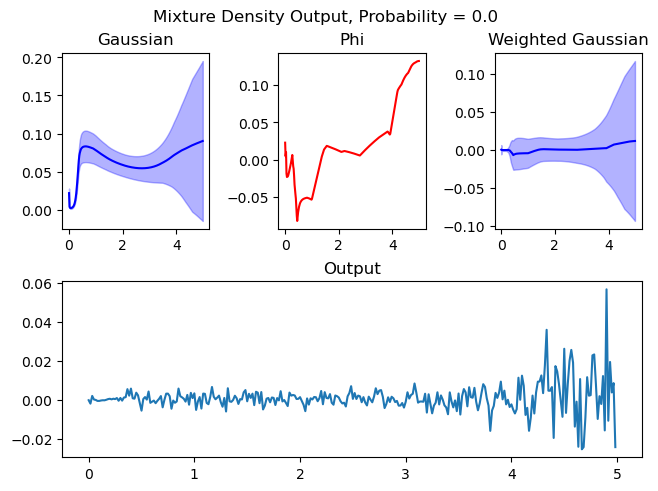

torch.Size([300, 2])


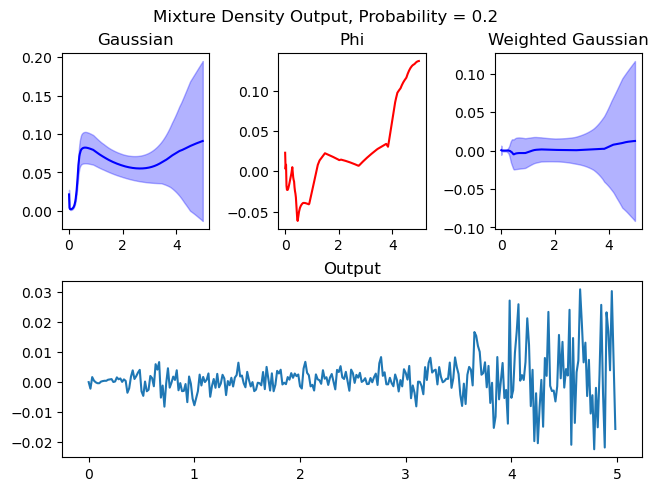

torch.Size([300, 2])


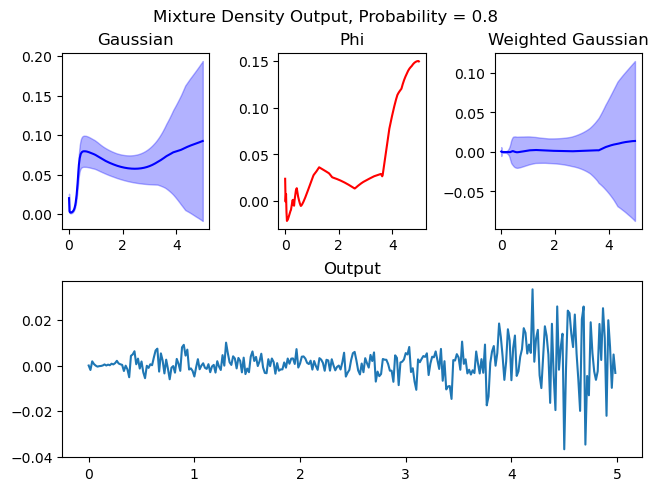

torch.Size([300, 2])


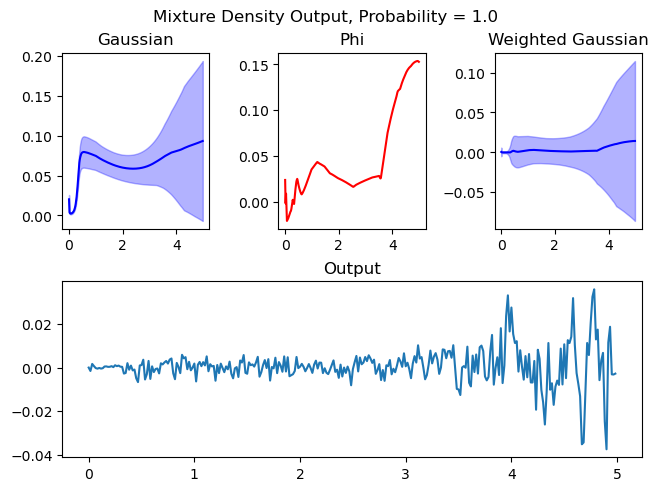

Epoch 57/64:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 57/64, Loss: -5.0003


Epoch 58/64:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 58/64, Loss: -4.1667


Epoch 59/64:   0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 62/64, Loss: -1.9344


Epoch 63/64:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 63/64, Loss: -4.6669


Epoch 64/64:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 64/64, Loss: -4.6812


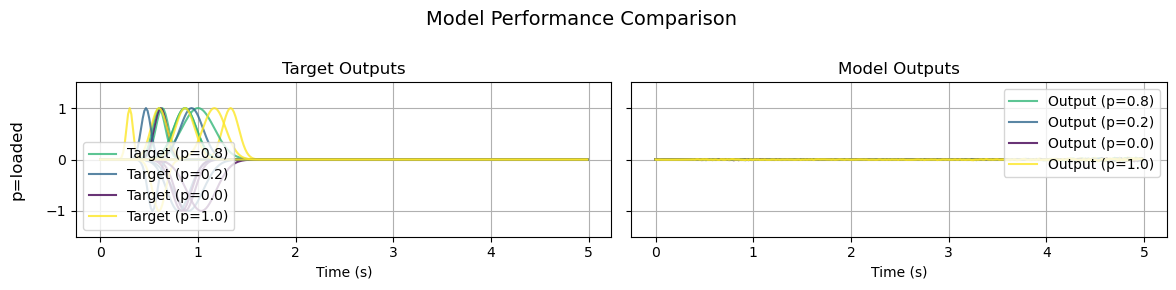

2025-06-30 17:59:29,852 - INFO - Initialized Dataset in GENERATE mode with 64 samples.


torch.Size([300, 2])


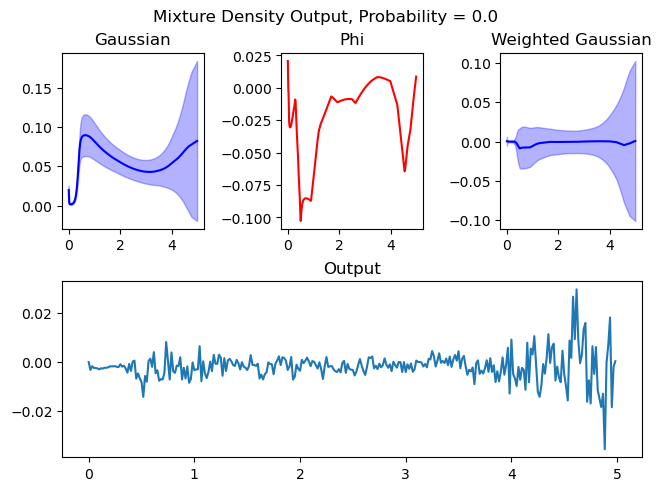

torch.Size([300, 2])


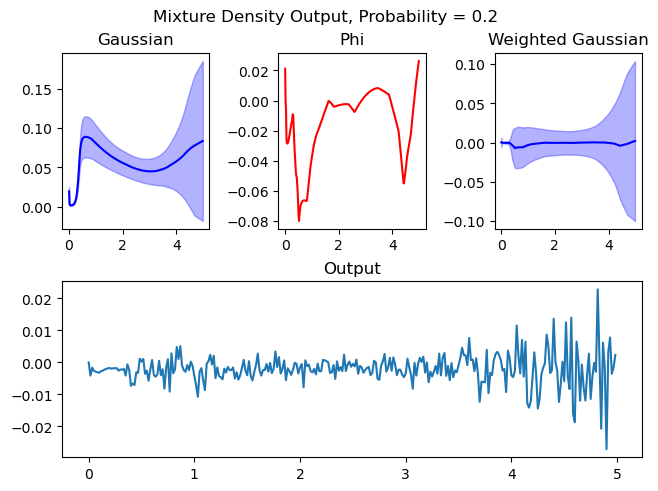

torch.Size([300, 2])


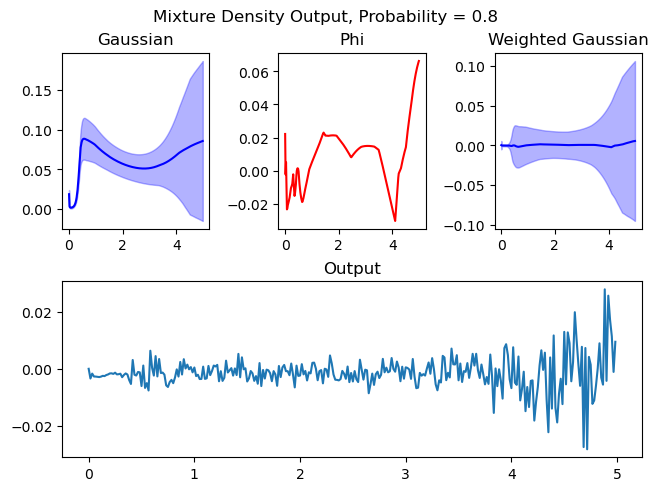

torch.Size([300, 2])


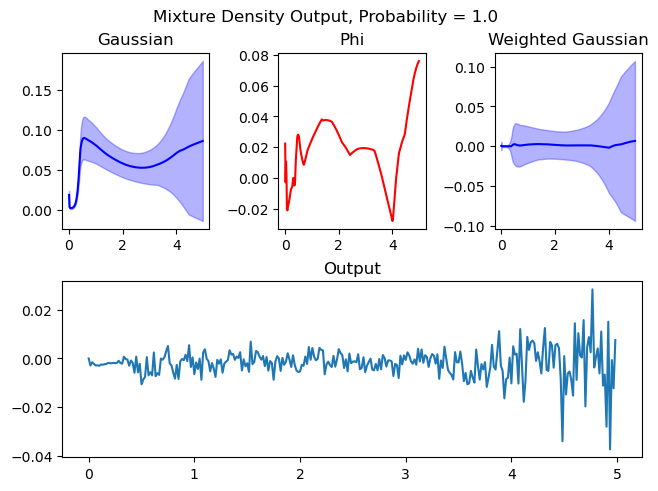

Training Complete!


In [9]:
# model = rmdn.RMDN(TRAINING_PARAMS['hidden_size'], 
#                   input_size=2)

model = rgn.RGN(TRAINING_PARAMS['hidden_size'],
                input_size=2)

if device != 'cpu':
    model = model.to(device)

optimizer = torch.optim.AdamW(model.parameters(),
                              lr=TRAINING_PARAMS['initial_learning_rate'],
                              betas=(0.9, 0.999),
                              weight_decay=5e-4)

def lr_lambda(epoch, warmup_epochs=8, total_epochs=TRAINING_PARAMS['num_epochs']):
    if epoch < warmup_epochs:
        return epoch / warmup_epochs
    else:
        progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
        return 0.1 + 0.9 * 0.5 * (1 + math.cos(math.pi * progress)) # Less aggressive decay
    
scheduler = LambdaLR(optimizer, lr_lambda)

epoch_progress = tqdm(range(TRAINING_PARAMS['num_epochs']), 
                      desc="Training Progress", 
                      position=0, 
                      leave=True)

for epoch in epoch_progress:
    epoch_loss = 0
    
    progress_bar = tqdm(dataloader, 
                        desc=f"Epoch {epoch+1}/{TRAINING_PARAMS['num_epochs']}", 
                        position=1,
                        leave=False)

    for inputs, targets, _ in progress_bar: # three return values for load mode, two for generate
        optimizer.zero_grad()

        if device != 'cpu':
            inputs, targets = inputs.to(device, non_blocking=True), targets.unsqueeze(-1).to(device, non_blocking=True)

        # Forward Pass
        #pis, mus, sigmas, output = model(inputs, epoch, TRAINING_PARAMS['num_epochs'], train=True, outputs=targets)
        phis, mus, sigmas, output = model(inputs, epoch, TRAINING_PARAMS['num_epochs'], train=True, outputs=targets)
        loss = rgn.nll_loss(phis, mus, sigmas, targets)
        #loss = rmdn.mdn_loss(pis, mus, sigmas, output, targets, inputs[:, :, 0] + 0.5) # s.t. probs are true probabilities
        
        # Backward Pass
        loss.backward()
        
        # Optimization Step
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_loss += loss.item()

    scheduler.step()
    print(f"Epoch {epoch + 1}/{TRAINING_PARAMS['num_epochs']}, Loss: {epoch_loss / len(dataloader):.4f}")

    if (epoch + 1) % 8 == 0:
        #utils.visualize_performance(model, dataset, [0.0, 0.2, 0.8, 1.0], 5) # Use for synthetic dataset
        utils.visualize_performance(model, dataset, None, 20) # Use for loaded dataset

        with torch.no_grad():
            model.eval()
            viz_dataset = decision_dataset.DecisionDataset(generate=True, num_samples=64)
            for p in [0.0, 0.2, 0.8, 1.0]:
                inputs, _ = viz_dataset.__getitem__(index=None, p=p)
                print(inputs.shape)
                inputs = inputs.unsqueeze(0)
                
                #pi, mu, sigma, output = model(inputs, train=False)
                #visualize_mixture_components(pi, mu, sigma, output, viz_dataset.time, p)

                phi, mu, sigma, output = model(inputs, train=False)
                visualize_gaussian(phi, mu, sigma, output, viz_dataset.time, p)

    if (epoch + 1) % 8 == 0:
        weights_name = f'weights/model_weights_epoch_{epoch + 1}_hidden_size_32_rgn'
        torch.save(model.state_dict(), weights_name)

print("Training Complete!")